<a href="https://colab.research.google.com/github/Iqbal2705/Kelompok3_ProbabilitasStatistika_CloudGaming/blob/main/FinalKelompok3_ProbabilitasStatistika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# IMPORT LIBRARY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from google.colab import files
import io, os

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

print("Library berhasil dimuat.")


Library berhasil dimuat.


In [ ]:
# ============================================================
# UPLOAD DATASET EXCEL
# ============================================================
uploaded = files.upload()

filename = next(iter(uploaded))
df = pd.read_excel(io.BytesIO(uploaded[filename]), sheet_name='Dataset')

print("Nama file:", filename)
print("Ukuran dataset:", df.shape)
print("\n5 data pertama:")
display(df.head())


Saving 3TIC_03_ComprehensiveCloudWorkloadPerformance.xlsx to 3TIC_03_ComprehensiveCloudWorkloadPerformance.xlsx
Nama file: 3TIC_03_ComprehensiveCloudWorkloadPerformance.xlsx
Ukuran dataset: (5000, 49)

5 data pertama:


,Job_ID,Task_Start_Time,Task_End_Time,CPU_Utilization (%),Memory_Consumption (MB),Task_Execution_Time (ms),System_Throughput (tasks/sec),Task_Waiting_Time (ms),Data_Source,Number_of_Active_Users,Network_Bandwidth_Utilization (Mbps),Job_Priority,Scheduler_Type,Resource_Allocation_Type,Error_Rate (%),Task_Type,Projection_Score,Predicted_Execution_Duration (ms),Predicted_Context_Switch_Penalty (ms),Host_Cluster_Suitability_Score,Predicted_Load_Condition,Scheduling_Priority_Score,Resource_Cluster_ID,Load_Rebalancing_Flag,Envy_Freeness_Score,VM_Placement_Diversity_Score,PM_Utilization_Efficiency (%),Affinity_Breaker_Flag,Observed_Delay_Deviation (ms),Adaptive_Model_Update_Flag,Context_Switch_Overhead (%),Thermal_Impact_Score,Energy_Efficiency_Index,Predicted_Host_ID,Actual_Host_ID,CPU_Share (%),Memory_Share (%),Bandwidth_Share (%),VM_Total_Memory_Capacity (MB),Host_Selection_Correct,Envy_Rate (%),Dominant_Resource_Share (%),Memory_Utilization (%),Security_Threat_Score,Residual_Attack_Surface,Immutability_Flag,Migration_Need,Drift_Index,Socket_Starvation_Index
0,JOB_1,2024-01-01 00:00:00,2024-01-01 00:00:00,3996,3622,2734,903,83,IoT,3000,11297,Low,FCFS,Static,165,CPU-Bound,1027,2522,115,728,Low,486,Cluster_1,No,831,967,831,No,212,Yes,98,818,1215,Host_1,Host_3,6887,2278,5496,8192,0,169,6887,4421,4,33,1,1,775,621.000
1,JOB_2,2024-01-01 00:01:00,2024-01-01 00:01:00,8606,5690,2868,803,64,Social Media,4590,3292,Low,Priority-Based,Dynamic,292,IO-Bound,708,2856,93,758,High,964,Cluster_2,Yes,741,572,7527,Yes,12,Yes,55,538,1438,Host_2,Host_4,3316,1886,1816,32768,0,259,3316,1736,7,428,0,1,42,"2,094.000"
2,JOB_3,2024-01-01 00:02:00,2024-01-01 00:02:00,6856,5075,1311,569,971,Cloud,3780,54282,Low,Priority-Based,Static,26,Delay-Sensitive,1424,1150,71,819,High,662,Cluster_3,No,802,891,8464,Yes,161,No,221,649,1276,Host_3,Host_3,8131,6684,9378,32768,1,198,9378,1549,5,109,0,0,1228,"3,734.000"
3,JOB_4,2024-01-01 00:03:00,2024-01-01 00:03:00,5789,7686,875,451,757,Social Media,4474,97394,Medium,Priority-Based,Dynamic,133,Memory-Intensive,141,788,71,732,Low,189,Cluster_4,Yes,923,883,9251,Yes,87,Yes,206,676,1075,Host_1,Host_3,8868,6935,3904,16384,0,77,8868,4691,4,117,0,1,994,"2,895.000"
4,JOB_5,2024-01-01 00:04:00,2024-01-01 00:04:00,2248,2297,1260,638,581,Enterprise DB,1981,40538,Low,FCFS,Static,199,Memory-Intensive,773,1236,65,844,Low,82,Cluster_5,Yes,819,728,8294,Yes,24,No,186,613,817,Host_4,Host_2,7254,8822,6861,16384,0,181,8822,1402,3,272,0,1,19,"4,072.000"


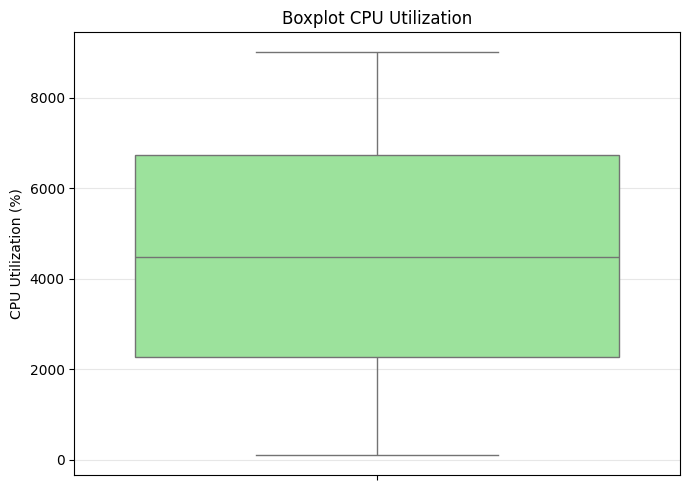

In [ ]:
# ============================================================
# CHART 1: BOXPLOT CPU UTILIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.boxplot(
    y=df['CPU_Utilization (%)'],
    color='lightgreen'
)

plt.title('Boxplot CPU Utilization')
plt.ylabel('CPU Utilization (%)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

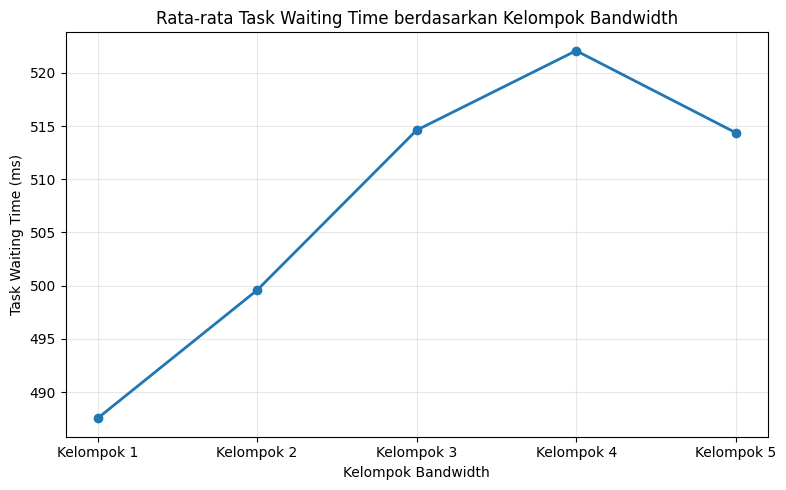

In [ ]:
# ============================================================
# CHART 2: LINE CHART
# RATA-RATA TASK WAITING TIME BERDASARKAN KELOMPOK BANDWIDTH
# ============================================================

# Membagi bandwidth menjadi 5 kelompok
df['Bandwidth_Group'] = pd.qcut(
    df['Network_Bandwidth_Utilization (Mbps)'],
    q=5,
    labels=[
        'Kelompok 1',
        'Kelompok 2',
        'Kelompok 3',
        'Kelompok 4',
        'Kelompok 5'
    ]
)

# Menghitung rata-rata Task Waiting Time
mean_waiting = df.groupby(
    'Bandwidth_Group',
    observed=False
)['Task_Waiting_Time (ms)'].mean()

plt.figure(figsize=(8, 5))

plt.plot(
    mean_waiting.index,
    mean_waiting.values,
    marker='o',
    linewidth=2
)

plt.title('Rata-rata Task Waiting Time berdasarkan Kelompok Bandwidth')
plt.xlabel('Kelompok Bandwidth')
plt.ylabel('Task Waiting Time (ms)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

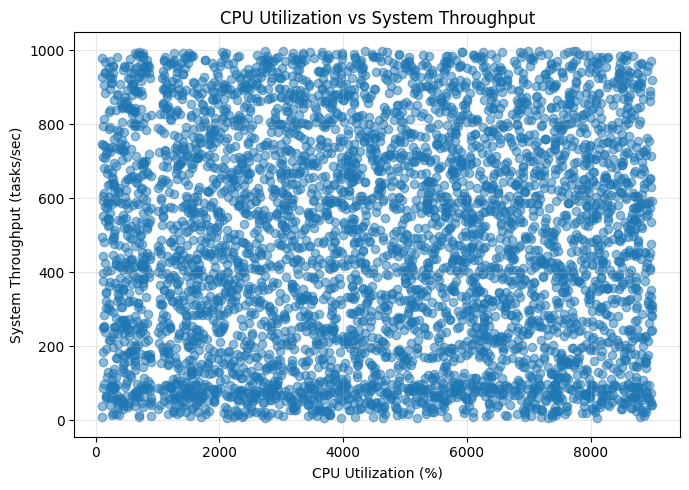

In [ ]:
# ============================================================
# CHART 3: SCATTER PLOT
# CPU UTILIZATION VS SYSTEM THROUGHPUT
# ============================================================

plt.figure(figsize=(7, 5))

plt.scatter(
    df['CPU_Utilization (%)'],
    df['System_Throughput (tasks/sec)'],
    alpha=0.5
)

plt.title('CPU Utilization vs System Throughput')
plt.xlabel('CPU Utilization (%)')
plt.ylabel('System Throughput (tasks/sec)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

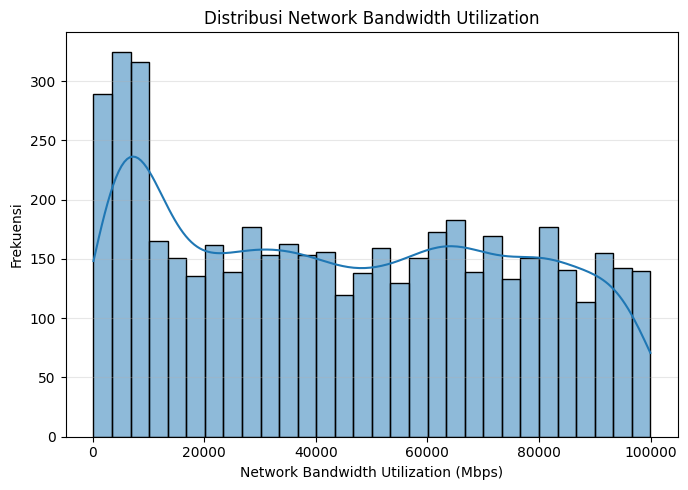

In [ ]:
# ============================================================
# CHART 4: HISTOGRAM NETWORK BANDWIDTH UTILIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.histplot(
    df['Network_Bandwidth_Utilization (Mbps)'],
    bins=30,
    kde=True
)

plt.title('Distribusi Network Bandwidth Utilization')
plt.xlabel('Network Bandwidth Utilization (Mbps)')
plt.ylabel('Frekuensi')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()